In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

import os
import torch
import argparse
import yaml
from numba import cuda

from helpers.density_estimator import DensityEstimator
from helpers.ANODE_training_utils import train_ANODE, plot_ANODE_losses
from helpers.data_transforms import preprocess_data, inverse_preprocess_data
from sklearn.preprocessing import StandardScaler, MinMaxScaler


from helpers.flow_sampling import get_flow_samples
from helpers.evaluation import get_kl_dist, discriminate_data_from_samples


/global/homes/r/rmastand/.local/lib/python3.8/site-packages/zfit/__init__.py:63: UserWarning: TensorFlow warnings are by default suppressed by zfit. In order to show them, set the environment variable ZFIT_DISABLE_TF_WARNINGS=0. In order to suppress the TensorFlow warnings AND this warning, set ZFIT_DISABLE_TF_WARNINGS=1.
  warnings.warn(


In [2]:
SEED = 8
BATCH_SIZE = 1024
NUM_FEATURES = 5
EPOCHS = 50
PATIENCE = 5
CONFIG = "DIFFUSION_0"
TRAIN_FLOW = False
TRAIN_DIFFUSION_MODEL = True

In [3]:

# computing
device = cuda.get_current_device()
device.reset()
torch.set_num_threads(2)
device = torch.device( "cuda" if torch.cuda.is_available() else "cpu")
print( "Using device: " + str( device ), flush=True)
seed = int(SEED)
torch.manual_seed(seed)
np.random.seed(seed)

Using device: cuda


In [4]:



path_to_config_file = f"configs/{CONFIG}.yml"
flow_training_dir = f"/pscratch/sd/r/rmastand/muon/models/{CONFIG}"
os.makedirs(flow_training_dir, exist_ok=True)



In [5]:
collections_TrackerHitPlane = [
    "IBTrackerHits",
    "IBTrackerHitsConed",
    "IETrackerHits", 
    "IETrackerHitsConed",
    "OBTrackerHits",
    "OBTrackerHitsConed", 
    "OETrackerHits",        
    "OETrackerHitsConed",          
    "VBTrackerHits",               
    "VBTrackerHitsConed",   
    "VETrackerHits",  
    "VETrackerHitsConed",        
]

collections_SimTrackerHit = [
  #  "InnerTrackerBarrelCollection",
   # "InnerTrackerBarrelCollectionConed",
   # "InnerTrackerEndcapCollection",
   # "InnerTrackerEndcapCollectionConed", 
    "OuterTrackerBarrelCollection",     
  #  "OuterTrackerBarrelCollectionConed",
#    "OuterTrackerEndcapCollection",  
  #  "OuterTrackerEndcapCollectionConed",
  #  "VertexBarrelCollection",   
  #  "VertexBarrelCollectionConed",   
  #  "VertexEndcapCollection",
  #  "VertexEndcapCollectionConed",
]


feature_labels = ["$E$", "$x$", "$y$", "$z$", "$t$", "noise"]

In [6]:

data = []

for collection in collections_SimTrackerHit: # TODO coned too?

    print(collection)
    
    tmp = np.load(f"/pscratch/sd/r/rmastand/muon/npys/{collection}_SimTrackerHit.npy")
    print(tmp.shape)
    data.append(tmp)

data = np.vstack(data)[:,[0,2,3,4,5]]
print(data.shape)


bins_dict = {}

for i in range(5):
    if i in [0, 4]:
        bins_dict[i] = np.logspace(np.log10(0.9*np.min(data[:,i])), np.log10(1.1*np.max(data[:,i])), 100) 
    else:
        bins_dict[i] = np.linspace(np.min(data[:,i] - 10), np.max(data[:,i] + 10), 100) 
bins_dict[5] = np.linspace(-5, 5, 100)

OuterTrackerBarrelCollection
(6787500, 6)
(6787500, 5)


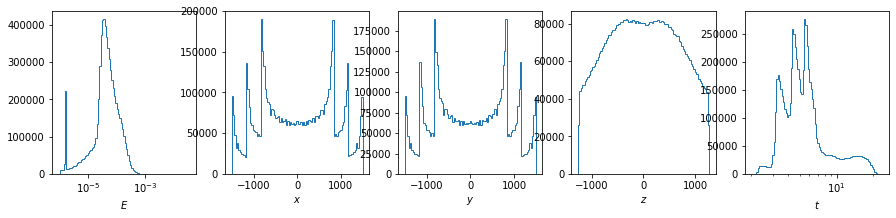

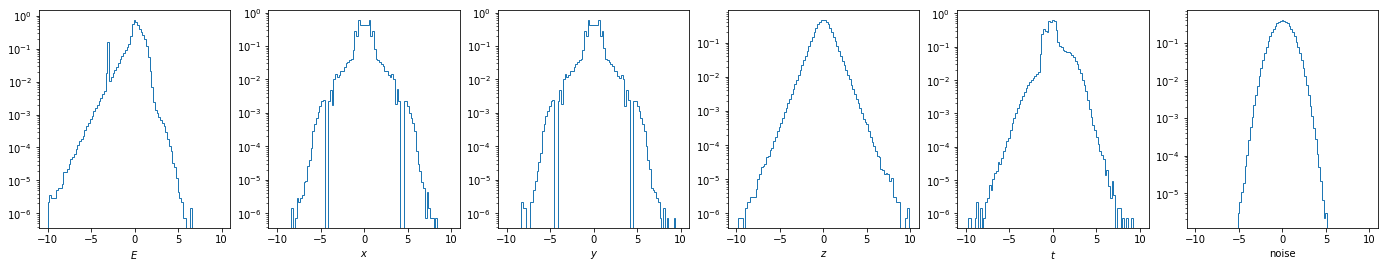

In [7]:
X_preproc = preprocess_data(data, ".")

fig, ax = plt.subplots(1, 5, figsize = (15, 3))
for i in range(5):
    ax[i].hist(data[:,i], bins = bins_dict[i], histtype = "step", label = "data")
    ax[i].set_xlabel(feature_labels[i])
    if i in [0, 4]:
        ax[i].set_xscale("log")
plt.show()

    

# add a random noise feature for now
X_preproc = np.hstack([X_preproc,  np.random.normal(size=(len(X_preproc),1))])


fig, ax = plt.subplots(1, 6, figsize = (24, 4))
for i in range(6):
    ax[i].hist(X_preproc[:,i], bins = np.linspace(-10, 10, 100), histtype = "step", density = True)
    ax[i].set_xlabel(feature_labels[i])
    ax[i].set_yscale("log")
plt.show()

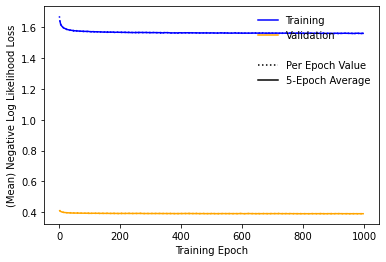

In [8]:


# plot losses
train_losses = np.load(os.path.join(flow_training_dir, f"flow_train_losses.npy"))
val_losses = np.load(os.path.join(flow_training_dir, f"flow_val_losses.npy"))
val_losses = val_losses[train_losses < 1e20]
train_losses = train_losses[train_losses < 1e20]
plot_ANODE_losses(train_losses, val_losses, yrange=None,
savefig=os.path.join(flow_training_dir, f"loss_plot"),suppress_show=False)



In [9]:
if TRAIN_FLOW:
    print("Making flow samples...")
    
    # get epoch of best val loss
    best_epoch = np.nanargmin(val_losses) - 1
    model_path = f"{flow_training_dir}/flow_epoch_{best_epoch}.par"
    
    eval_model = DensityEstimator(path_to_config_file, NUM_FEATURES,
                             eval_mode=True,
                             load_path=model_path,
                             device=device, verbose=False,
                             bound=False)

    

    X_samples = {
        "flow_samples":get_flow_samples(eval_model, masses=None, num_samples = data.shape[0])
    }


    
elif TRAIN_DIFFUSION_MODEL:

    with open(path_to_config_file, "r") as ifile:
        configs_dict = yaml.safe_load(ifile)

    from tqdm import tqdm
    import functools
    from helpers.models.diffusion.diffusion_model import ScoreNet1D, marginal_prob_std, diffusion_coeff
    from helpers.models.diffusion.samplers import Euler_Maruyama_sampler, pc_sampler, ode_sampler
    
    marginal_prob_std_fn = functools.partial(marginal_prob_std, sigma=configs_dict["sigma"], device=device)
    diffusion_coeff_fn = functools.partial(diffusion_coeff, sigma=configs_dict["sigma"], device=device)

    num_steps =  1000
    signal_to_noise_ratio = 0.16
    error_tolerance = 1e-6
    
    ## Load the pre-trained checkpoint from disk.
    device = 'cuda' #@param ['cuda', 'cpu'] {'type':'string'}
    score_model = torch.nn.DataParallel(ScoreNet1D(marginal_prob_std=marginal_prob_std_fn, channels=configs_dict["channels"], embed_dim=configs_dict["embed_dim"]))
    score_model = score_model.to(device)
    ckpt = torch.load(f"{flow_training_dir}/ckpt.pth", map_location=device)
    score_model.load_state_dict(ckpt)

    num_samples_total = data.shape[0] // 10
    sample_batch_size = 4096

    print("Running Euler_Maruyama_sampler...") 
    samples_EM = []
    for i in tqdm(range(0, num_samples_total, sample_batch_size)):
        if i + sample_batch_size > num_samples_total:
            nn = num_samples_total - i 
        else:
            nn = sample_batch_size
        loc_samples = Euler_Maruyama_sampler(score_model, marginal_prob_std_fn, diffusion_coeff_fn, NUM_FEATURES, 
                      nn, num_steps=num_steps, device=device).squeeze(1).detach().cpu().numpy()
        samples_EM.append(loc_samples)
    samples_EM = np.concatenate(samples_EM)
    print(samples_EM.shape)


    print("Running pc_sampler...") 
    samples_pc = []
    for i in tqdm(range(0, num_samples_total, sample_batch_size)):
        if i + sample_batch_size > num_samples_total:
            nn = num_samples_total - i 
        else:
            nn = sample_batch_size
        loc_samples = pc_sampler(score_model, marginal_prob_std_fn, diffusion_coeff_fn, NUM_FEATURES,
                      nn, num_steps=num_steps, snr=signal_to_noise_ratio, device=device).squeeze(1).detach().cpu().numpy()
        samples_pc.append(loc_samples)
    samples_pc = np.concatenate(samples_pc)
    print(samples_pc.shape)

    print("ode_sampler pc_sampler...") 
    samples_ode = []
    for i in tqdm(range(0, num_samples_total, sample_batch_size)):
        if i + sample_batch_size > num_samples_total:
            nn = num_samples_total - i 
        else:
            nn = sample_batch_size
        loc_samples = ode_sampler(score_model, marginal_prob_std_fn, diffusion_coeff_fn, NUM_FEATURES,
                      nn, atol=error_tolerance, rtol=error_tolerance, device=device).squeeze(1)
        samples_ode.append(loc_samples.detach().cpu().numpy())
    samples_ode = np.concatenate(samples_ode)
    print(samples_ode.shape)

    X_samples = {
        "samples_EM":samples_EM,
        "samples_pc":samples_pc,
        "samples_ode":samples_ode,
    }
    
    
    


Running Euler_Maruyama_sampler...


100%|██████████| 166/166 [05:00<00:00,  1.81s/it]


(678750, 5)
Running pc_sampler...


100%|██████████| 166/166 [10:06<00:00,  3.65s/it]


(678750, 5)
ode_sampler pc_sampler...


...

Number of function evaluations: 1964


 99%|█████████▉| 165/166 [11:21<00:04,  4.13s/it]

Number of function evaluations: 2000


100%|██████████| 166/166 [11:26<00:00,  4.13s/it]


(678750, 5)


In [10]:
for key in X_samples.keys():
    
    X_samples[key] = inverse_preprocess_data( X_samples[key] , flow_training_dir)


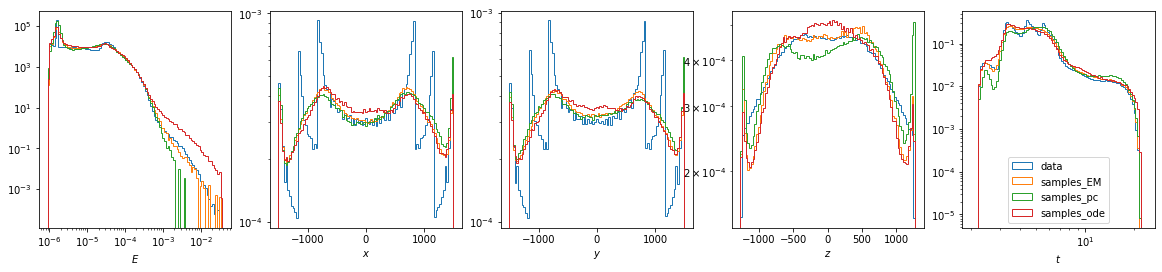

In [11]:



fig, ax = plt.subplots(1, 5, figsize = (20, 4))
for i in range(5):
    ax[i].hist(data[:,i], bins = bins_dict[i], histtype = "step", density = True, label = "data")
    for key in X_samples.keys():
        ax[i].hist(X_samples[key][:,i], bins = bins_dict[i], histtype = "step", density = True, label = key)
    ax[i].set_yscale("log")
    ax[i].set_xlabel(feature_labels[i])
    if i in [0, 4]:
        ax[i].set_xscale("log")
ax[-1].legend()
plt.show()



In [12]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np


def corner_hist2d(
    X,
    feature_labels,
    bins_dict,
    log_dims=(0, 4),
    title=None,
):
    """
    X : (N, D) array
    """
    D = X.shape[1]
    norm = LogNorm()

    fig, axes = plt.subplots(
        D, D,
        figsize=(2.5 * D, 2.5 * D),
        constrained_layout=True,
        sharex="col",
        #sharey="row",
    )

    mappable = None

    for i in range(D):
        for j in range(D):
            ax = axes[j, i]

            if j < i:
                ax.axis("off")
                continue

            if i == j:
                # 1D histogram on the diagonal
                ax.hist(
                    X[:, i],
                    bins=bins_dict[i],
                    density=True,
                    histtype = "step",
                )

                if i in log_dims:
                    ax.set_xscale("log")
                ax.set_yscale("log")
                ax.set_yticks([])

            else:
                h = ax.hist2d(
                    X[:, i],
                    X[:, j],
                    bins=[bins_dict[i], bins_dict[j]],
                    norm=norm,
                    density=True,
                )
                mappable = h[3]

                if i in log_dims:
                    ax.set_xscale("log")
                if j in log_dims:
                    ax.set_yscale("log")

            # y ticks only on left column
            if i != 0:
                ax.tick_params(axis="y", which="both", left=False, labelleft=False)
            
            # x ticks only on bottom row
            if j != D - 1:
                ax.tick_params(axis="x", which="both", bottom=False, labelbottom=False)

            

            # labels
            if j == D - 1:
                ax.set_xlabel(feature_labels[i])
            if i == 0 and j != i:
                ax.set_ylabel(feature_labels[j])

    if title is not None:
        fig.suptitle(title, fontsize=16)

    if mappable is not None:
        fig.colorbar(
            mappable,
            ax=axes,
            label="density",
            shrink=0.8,
        )

    plt.subplots_adjust(hspace=0, wspace=0)

    return fig, axes


/tmp/ipykernel_740822/2626600876.py:93: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(hspace=0, wspace=0)


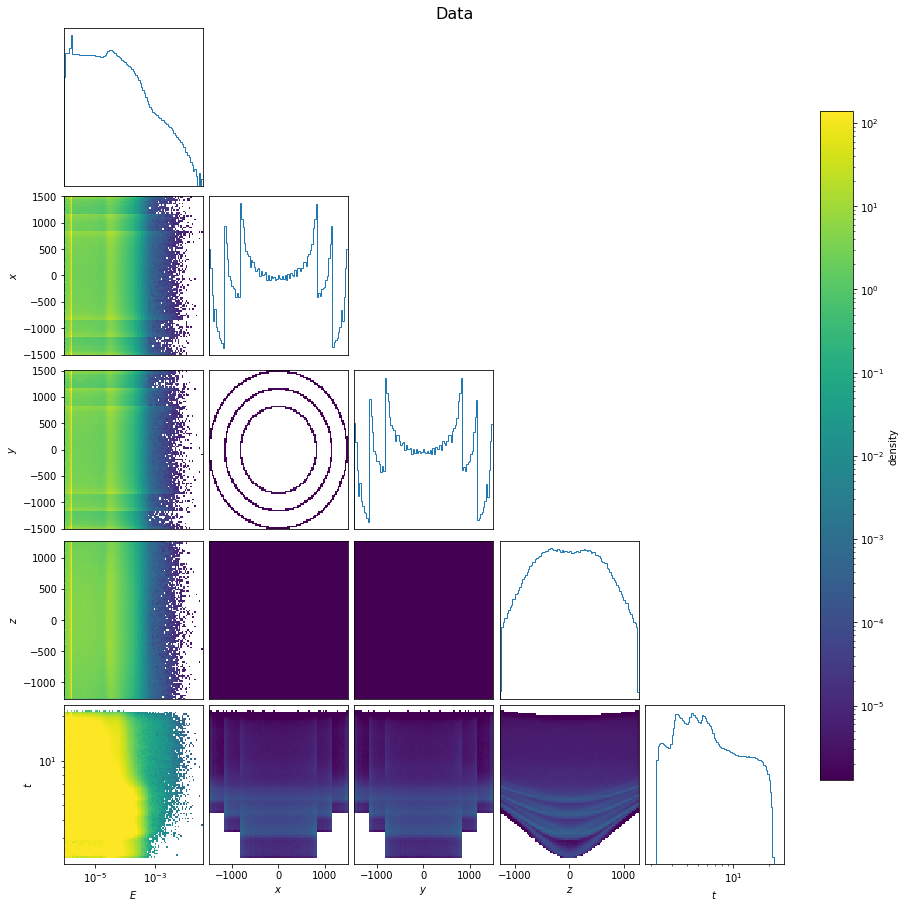

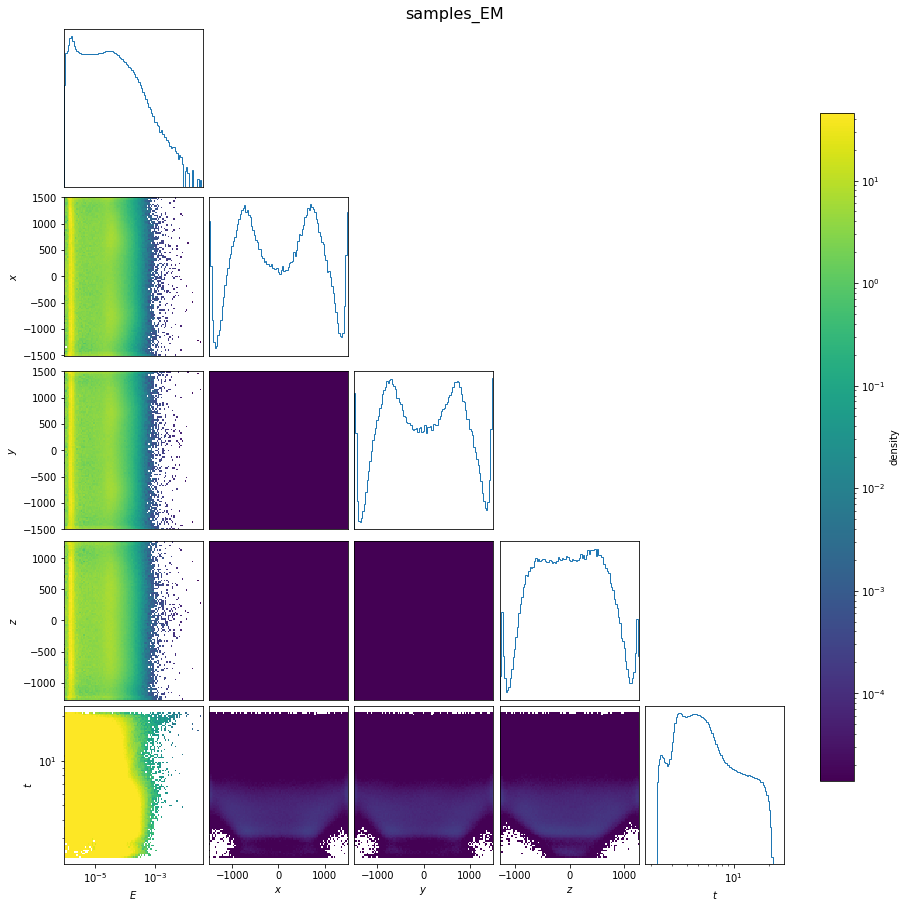

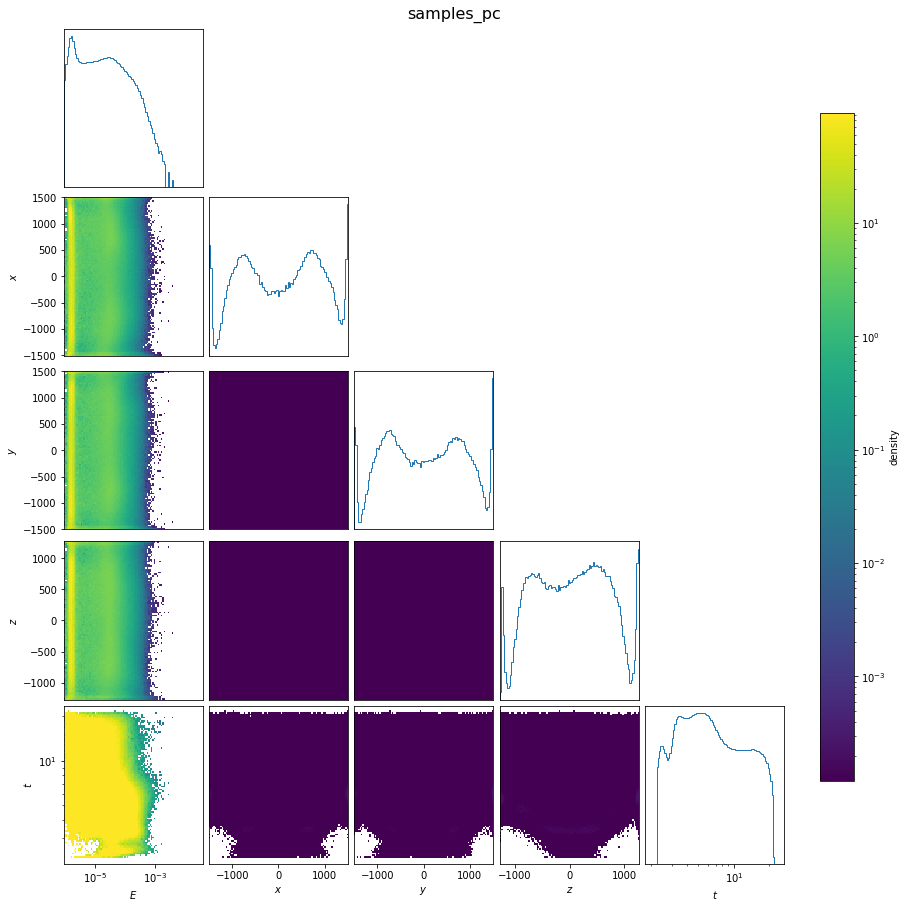

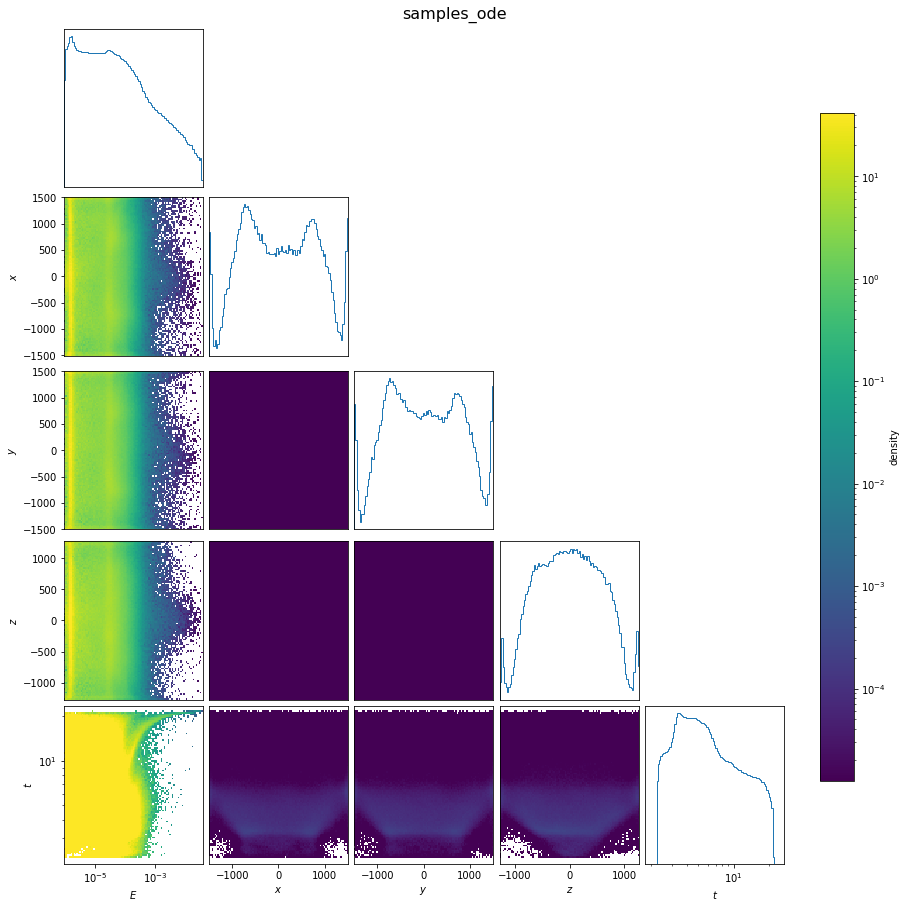

In [13]:
fig_data, axes_data = corner_hist2d(
    data,
    feature_labels=feature_labels,
    bins_dict=bins_dict,
    log_dims=(0, 4),
    title="Data",
)
plt.show()

for key in X_samples.keys():
    fig_samp, axes_samp = corner_hist2d(
        X_samples[key],
        feature_labels=feature_labels,
        bins_dict=bins_dict,
        log_dims=(0, 4),
        title= key,
    )


# Train a BDT to discriminate flow from samples

In [14]:


ks_dists_samples = get_kl_dist(data, X_sample)
ks_dists_gaussians = get_kl_dist(np.random.normal(size = data.shape), np.random.normal(size = X_sample.shape))

                                        
for i, ks_dist in enumerate(ks_dists_samples):
    print("Feature {i} KL div: {ks_dist} (for gaussian: {ks_gauss})".format(i=i, ks_dist=ks_dist, ks_gauss=ks_dists_gaussians[i]))
    


auc_mean, auc_std, best_epoch, max_epochs = discriminate_data_from_samples(data, X_sample, n_runs=10, bdt_config="configs/bdt.yml")
print(f"auc {auc_mean} \pm {auc_std}. best epoch {best_epoch} of {max_epochs}.\n")



NameError: name 'X_sample' is not defined